# Résonateur de lecture

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
from IPython.display import Image, display
from scipy.optimize import curve_fit
import scipy.constants as sc
path_fig="..//Figures/"
path_Sonnet="..//Sonnet/"

On cherche à simuler le résonateur de lectrue ci-dessus. La longueur totale du résonateur $\lambda/4$ est $L_{\mathrm{Res.}}= 4.841 \, \mathrm{mm}$ et la tension est sondé par le port 2 à travers une capacité de couplage $C_{\mathrm{c}}= 1 \, \mathrm{fF}$ (voir ci-dessous). 

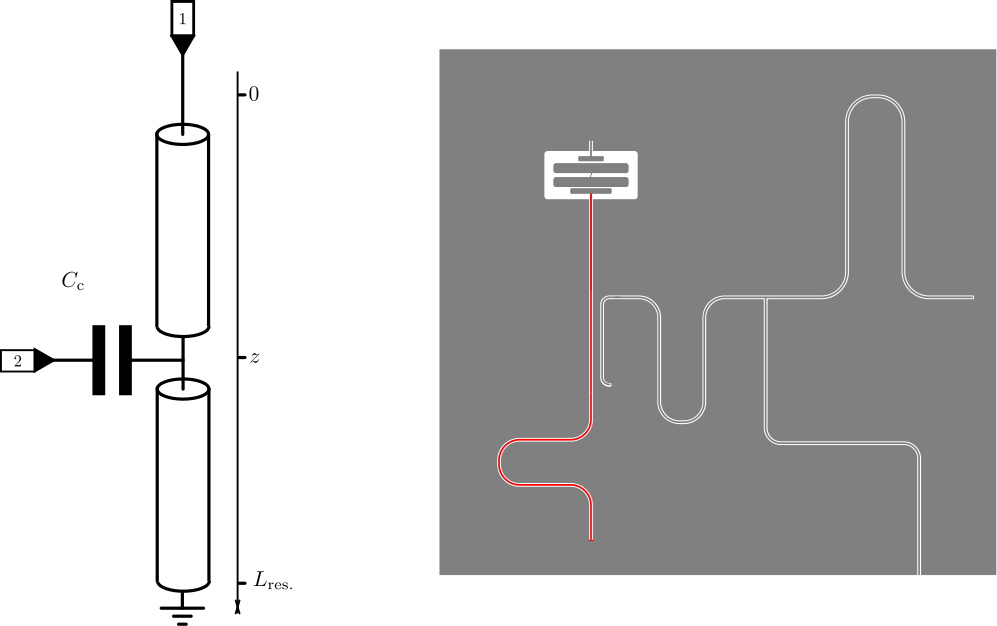

In [6]:
Image(filename=path_fig+"Resonator.png", width=600)

- Créer deux lignes de transmission skrf définies respectivement par une longeur $z$ et $L_{\mathrm{Res.}}-z$, une impédance caractéristique $Z_0= 54.93 \Omega$ et une vitesse de propagation $v=1.26 \times 10^8 \, \mathrm{m.s}^{-1}$ en vous aidant de l'exemple ci-dessous:

        s_line = np.zeros((Nf, 2, 2), dtype=complex)

        s_line[:, 0, 1] = np.exp(-1j * 2 * np.pi * f / c * L)

        s_line[:, 1, 0] = np.exp(-1j * 2 * np.pi * f / c * L)

        CPW= rf.Network(frequency=freq, s=s_line, z0=50, name='CPW_a_b')

- Créer 2 [ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Port.html), un [open](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Open.html) et un [élément de circuit discret simulant la capacité](https://scikit-rf.readthedocs.io/en/latest/examples/circuit/Lumped%20Element%20Circuits.html) $C_c$,
- Mesurer la fréquence de résonance $f_0$ sachant que $\mathrm{Im} Y(f_0)=0$, 
- Créer des [connexions](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.connections_list.html) simulant le circuit ci-dessus pour différentes valeur de $\ell$. Chaque connexion permet de sonder la tension dans le résonateur quart d’onde au niveau de la cote $z=\ell$.